In [46]:
import scanpy as sc
import numpy as np
import anndata as ad
import os
import palantir
import palantir.utils
import palantir.plot
import pandas as pd
from scipy.spatial.distance import cdist

In [47]:
def compute_palantir(adata, start_cluster, n_times=6, end_time=80):
    
    
    # 1. Sélection des cellules
    is_in = adata.obs['leiden'].isin(start_cluster)
    is_out = ~is_in

    # Tu peux travailler sur adata.X ou adata.obsm['X_pca'], selon ce que tu veux
    X_in = adata[is_in].obsm['X_pca']  # ou adata.X
    X_out = adata[is_out].obsm['X_pca']
    
    # 2. Calcul des distances (chaque ligne = une cellule de X_in, colonnes = distances aux autres)
    D = cdist(X_in, X_out, metric='euclidean')  # ou 'cosine' etc.

    # 3. Distance moyenne de chaque cellule de start_cluster vers les autres
    avg_distances = D.mean(axis=1)  # ou .min(axis=1) ou .max(axis=1)

    # 4. Trouve l'index de la cellule la plus "loin"
    best_idx = np.argmax(avg_distances)

    # 5. Récupère son nom
    start_cell = adata[is_in].obs_names[best_idx]


    # Convertir la matrice PCA en DataFrame avec noms de cellules comme index
    pca_df = pd.DataFrame(adata.obsm['X_pca'], index=adata.obs_names)

    # ⏳ Lancer Palantir
    dm_res = palantir.utils.run_diffusion_maps(pca_df, n_components=30)
    ms_data = palantir.utils.determine_multiscale_space(dm_res)
    palantir_results = palantir.core.run_palantir(ms_data, early_cell=start_cell, num_waypoints=500)

    # 📊 Ajouter le pseudotemps à l’objet AnnData
    adata.obs['palantir_pseudotime'] = palantir_results.pseudotime.values

    adata.obs['temporal_bin'] = pd.qcut(adata.obs['palantir_pseudotime'], q=n_times, labels=False)
    times = np.linspace(0, end_time, n_times)
    print(times)
    for cnt in range(0, n_times):
        adata.obs.loc[adata.obs['temporal_bin'] == cnt, 'new_time'] = times[cnt]
    
    return adata

In [48]:
# 📁 Chemin vers les fichiers
adata = ad.read_h5ad('./../tests/Semrau/Data/data.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 2449 × 41
    obs: 'time'
    var: 'd0', 'd1'


In [49]:
# Pour Scanpy :
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/opt/homebrew/Caskroom/miniconda/base/envs/cardamom/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:243: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


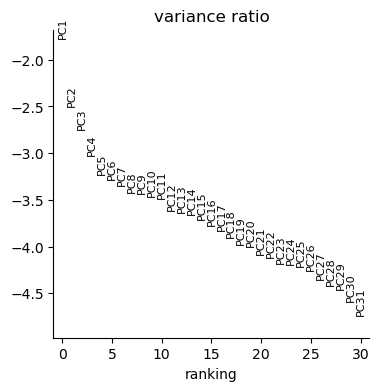

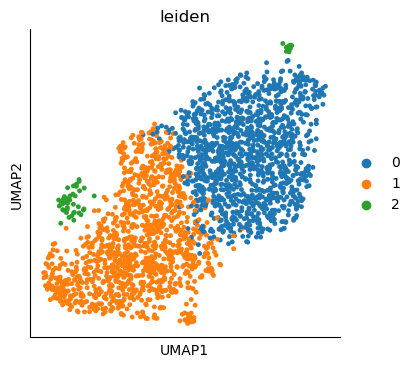

In [50]:
# 🔬 PCA + UMAP

sc.tl.pca(adata, svd_solver='arpack')

# Choisir les PCs avec ElbowPlot
sc.pl.pca_variance_ratio(adata, log=True)

sc.pp.neighbors(adata, n_pcs=9)
sc.tl.leiden(adata, resolution=.2)
sc.tl.umap(adata)

# 🔍 Visualisation
sc.pl.umap(adata, color=['leiden'])

/opt/homebrew/Caskroom/miniconda/base/envs/cardamom/lib/python3.12/site-packages/palantir/utils.py:354: RuntimeWarning: divide by zero encountered in divide
  dists /= adaptive_std[x]


Sampling and flocking waypoints...
Time for determining waypoints: 0.00044304927190144856 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.007352944215138753 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9990
Correlation at iteration 2: 0.9999
Correlation at iteration 3: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
[ 0. 12. 24. 36. 48. 60. 72. 84. 96.]


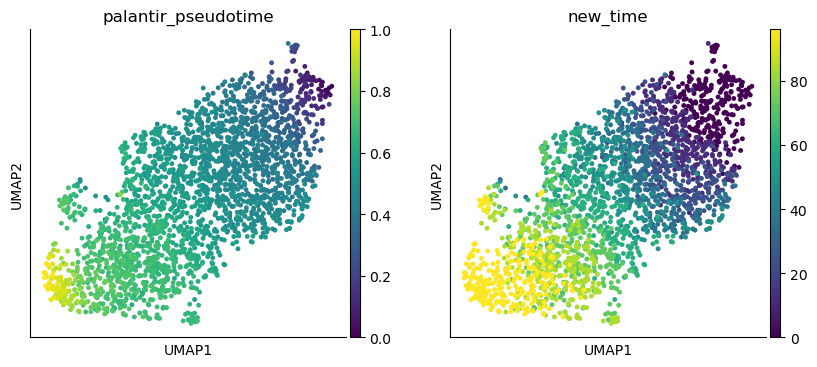

In [51]:
# 🧭 Définir l'index de la cellule de départ (par cluster Leiden)
start_cluster = ['0']
adata = compute_palantir(adata, start_cluster, n_times=9, end_time=96)

# Visualiser sur UMAP
sc.pl.umap(adata, color=['palantir_pseudotime', 'new_time'], cmap='viridis')

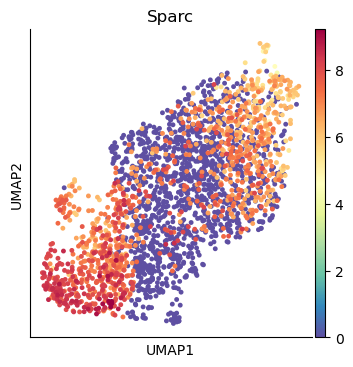

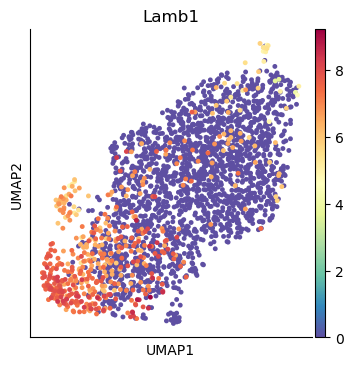

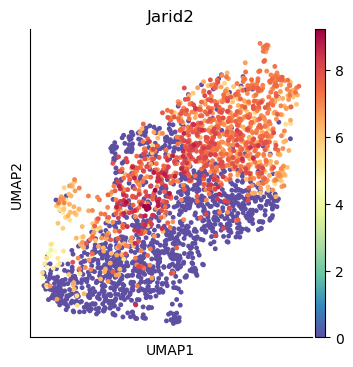

In [52]:
# 🔍 Visualisation
sc.pl.umap(adata, color='Sparc')
sc.pl.umap(adata, color='Lamb1')
sc.pl.umap(adata, color='Jarid2')



